In [1]:
from pathlib import Path

PROJECT_ROOT = Path("..")
MODEL_RESULTS = PROJECT_ROOT / "model_results"
GENERATED_RESULTS = PROJECT_ROOT / "generated_results"
GENERATED_RESULTS.mkdir(exist_ok=True)

In [2]:
from collections import Counter
from pathlib import Path


def find_resamples(model_results, complete_only=False):
    """Resample indices found under model_results/*/Predictions/*/.

    complete_only=True keeps only those present for every classifier x dataset pair.
    """
    counts, pairs = Counter(), set()
    for f in Path(model_results).glob("*/Predictions/*/testResample*.csv"):
        idx = f.stem.removeprefix("testResample")
        if idx.isdigit():
            counts[int(idx)] += 1
            pairs.add((f.parents[2].name, f.parent.name))
    if complete_only:
        return sorted(r for r, n in counts.items() if n == len(pairs))
    return sorted(counts)


In [3]:
# Auto-discover classifiers and common datasets from disk
classifiers = sorted(p.name for p in MODEL_RESULTS.iterdir() if p.is_dir())
print("Classifiers found:", classifiers)

# dataset_sets = [
#     set(p.name for p in (MODEL_RESULTS / c / "Predictions").iterdir() if p.is_dir())
#     for c in classifiers
# ]
# datasets = sorted(set.intersection(*dataset_sets))
from aeon.datasets.tsc_datasets import univariate_equal_length

datasets = univariate_equal_length
print(f"Common datasets: {len(datasets)}")

# Detect available resamples from any classifier/dataset combo
# sample_files = list((MODEL_RESULTS / classifiers[0] / "Predictions" / datasets[0]).glob("testResample*.csv"))
# resamples = sorted(int(f.stem.replace("testResample", "")) for f in sample_files)
resamples = find_resamples(MODEL_RESULTS)
# resamples = [0,1,2,3,4,5]
print(f"Resamples: {resamples}")

Classifiers found: ['Catch22', 'FreshPRINCE', 'HIVECOTEV2', 'MultiRocketHydra', 'QUANT', 'RDST', 'ROCKET', 'TSCGlueEnhancedV4-Best-LogLoss-GPU', 'TSCGlueEnhancedV4-High-Accuracy-GPU', 'TSCGlueEnhancedV4-High-LogLoss-GPU', 'TSCGlueEnhancedV4-Low-Accuracy-GPU', 'TSCGlueEnhancedV4-Low-LogLoss-GPU', 'TSCGlueEnhancedV4-Medium-Accuracy-GPU', 'TSCGlueEnhancedV4-Medium-LogLoss-GPU', 'WEASEL_V2']
Common datasets: 112
Resamples: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


In [4]:
# Display names used by tsml_eval (figures, CSVs). Classifiers not listed keep their directory name.
RENAME = {
    # "HIVECOTEV2": "HC2",
}
_metric_map = {"Accuracy": "accuracy", "F1": "f1", "LogLoss": "log_loss", "ROCAUC": "roc_auc"}
for c in classifiers:
    if c.startswith("TSCGlueEnhancedV4-") and c.endswith("-GPU"):
        preset, metric = c.removeprefix("TSCGlueEnhancedV4-").removesuffix("-GPU").split("-")
        RENAME.setdefault(c, f"TSCGlue-{preset.lower()}-{_metric_map[metric]}")

# Columns of tsml_eval's per-metric CSVs are always the sorted display names.
EVAL_NAMES = sorted(RENAME.get(c, c) for c in classifiers)
RENAME

{'TSCGlueEnhancedV4-Best-LogLoss-GPU': 'TSCGlue("best", "log_loss")',
 'TSCGlueEnhancedV4-High-Accuracy-GPU': 'TSCGlue("high", "accuracy")',
 'TSCGlueEnhancedV4-High-LogLoss-GPU': 'TSCGlue("high", "log_loss")',
 'TSCGlueEnhancedV4-Low-Accuracy-GPU': 'TSCGlue("low", "accuracy")',
 'TSCGlueEnhancedV4-Low-LogLoss-GPU': 'TSCGlue("low", "log_loss")',
 'TSCGlueEnhancedV4-Medium-Accuracy-GPU': 'TSCGlue("medium", "accuracy")',
 'TSCGlueEnhancedV4-Medium-LogLoss-GPU': 'TSCGlue("medium", "log_loss")'}

In [5]:
# classifiers.remove('TSCGlueEnhancedV4-Low-LogLoss-GPU')
# classifiers.remove('HIVECOTEV2')


# Count missing combinations (classifier x dataset x resample)
total = len(classifiers) * len(datasets) * len(resamples)
print(total, len(classifiers), len(datasets), len(resamples))
missing = 0
missing_list = []
for c in classifiers:
    for d in datasets:
        for r in resamples:
            path = MODEL_RESULTS / c / "Predictions" / d / f"testResample{r}.csv"
            if not path.exists():
                missing += 1
                missing_list.append((c, d, r))

print(f"Total combinations : {total}")
print(f"Present            : {total - missing}")
print(f"Missing            : {missing}")

per_model = len(datasets) * len(resamples)
print(f"\nMissing per model (out of {per_model}):")
for c in classifiers:
    n = sum(1 for mc, _, _ in missing_list if mc == c)
    if n:
        print(f"  {c:<35} {n}")

if missing_list:
    print("\nFirst 40 missing:")
    for c, d, r in missing_list[:40]:
        print(f"  {c} / {d} / resample {r}")

26880 15 112 16
Total combinations : 26880
Present            : 26869
Missing            : 11

Missing per model (out of 1792):
  TSCGlueEnhancedV4-Best-LogLoss-GPU  11

First 40 missing:
  TSCGlueEnhancedV4-Best-LogLoss-GPU / Crop / resample 0
  TSCGlueEnhancedV4-Best-LogLoss-GPU / ElectricDevices / resample 1
  TSCGlueEnhancedV4-Best-LogLoss-GPU / ElectricDevices / resample 2
  TSCGlueEnhancedV4-Best-LogLoss-GPU / ElectricDevices / resample 3
  TSCGlueEnhancedV4-Best-LogLoss-GPU / ElectricDevices / resample 5
  TSCGlueEnhancedV4-Best-LogLoss-GPU / ElectricDevices / resample 6
  TSCGlueEnhancedV4-Best-LogLoss-GPU / ElectricDevices / resample 7
  TSCGlueEnhancedV4-Best-LogLoss-GPU / ElectricDevices / resample 8
  TSCGlueEnhancedV4-Best-LogLoss-GPU / ElectricDevices / resample 10
  TSCGlueEnhancedV4-Best-LogLoss-GPU / ElectricDevices / resample 11
  TSCGlueEnhancedV4-Best-LogLoss-GPU / ElectricDevices / resample 12


In [6]:
from tsml_eval.evaluation import evaluate_classifiers_by_problem

evaluate_classifiers_by_problem(
    str(MODEL_RESULTS),
    [(c, RENAME.get(c, c)) for c in classifiers],
    datasets,
    str(GENERATED_RESULTS),
    resamples=resamples,
    error_on_missing=False,
    eval_name="tscbench",
    verbose=True,
    continue_on_missing=False,
)

Loaded Catch22 on ACSF1 test resample 0.
Loaded Catch22 on ACSF1 test resample 1.
Loaded Catch22 on ACSF1 test resample 2.
Loaded Catch22 on ACSF1 test resample 3.
Loaded Catch22 on ACSF1 test resample 4.
Loaded Catch22 on ACSF1 test resample 5.
Loaded Catch22 on ACSF1 test resample 6.
Loaded Catch22 on ACSF1 test resample 7.
Loaded Catch22 on ACSF1 test resample 8.
Loaded Catch22 on ACSF1 test resample 9.
Loaded Catch22 on ACSF1 test resample 10.
Loaded Catch22 on ACSF1 test resample 11.
Loaded Catch22 on ACSF1 test resample 12.
Loaded Catch22 on ACSF1 test resample 13.
Loaded Catch22 on ACSF1 test resample 14.
Loaded Catch22 on ACSF1 test resample 15.
Loaded Catch22 on Adiac test resample 0.
Loaded Catch22 on Adiac test resample 1.
Loaded Catch22 on Adiac test resample 2.
Loaded Catch22 on Adiac test resample 3.
Loaded Catch22 on Adiac test resample 4.
Loaded Catch22 on Adiac test resample 5.
Loaded Catch22 on Adiac test resample 6.
Loaded Catch22 on Adiac test resample 7.
Loaded Cat

/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/tsml_eval/evaluation/multiple_estimator_evaluation.py:1209: UserWarning: Number of jobs for Catch22 on ACSF1 test resample 2 is 2, which is different to the first result with 4. This may cause inconsistencies in timing results.
  warnings.warn(
/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/tsml_eval/evaluation/multiple_estimator_evaluation.py:1209: UserWarning: Number of jobs for Catch22 on ACSF1 test resample 3 is 2, which is different to the first result with 4. This may cause inconsistencies in timing results.
  warnings.warn(
/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/tsml_eval/evaluation/multiple_estimator_evaluation.py:1209: UserWarning: Number of jobs for Catch22 on ACSF1 test resample 4 is 2, which is different to the first result with 4. This may cause inconsistencies in timing results.
  warnings.warn(
/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/t



Estimator TSCGlue("best", "log_loss") is missing test results for Crop resample 0.
Estimator TSCGlue("best", "log_loss") is missing test results for ElectricDevices resample 1.
Estimator TSCGlue("best", "log_loss") is missing test results for ElectricDevices resample 2.
Estimator TSCGlue("best", "log_loss") is missing test results for ElectricDevices resample 3.
Estimator TSCGlue("best", "log_loss") is missing test results for ElectricDevices resample 5.
Estimator TSCGlue("best", "log_loss") is missing test results for ElectricDevices resample 6.
Estimator TSCGlue("best", "log_loss") is missing test results for ElectricDevices resample 7.
Estimator TSCGlue("best", "log_loss") is missing test results for ElectricDevices resample 8.
Estimator TSCGlue("best", "log_loss") is missing test results for ElectricDevices resample 10.
Estimator TSCGlue("best", "log_loss") is missing test results for ElectricDevices resample 11.
Estimator TSCGlue("best", "log_loss") is missing test results for E

/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/tsml_eval/evaluation/multiple_estimator_evaluation.py:1449: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  cd.savefig(
/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/tsml_eval/evaluation/multiple_estimator_evaluation.py:1449: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  cd.savefig(
/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/tsml_eval/evaluation/multiple_estimator_evaluation.py:1449: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  cd.savefig(
/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/tsml_eval/evaluation/multiple_estimator_evaluation.py:1449: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  

In [7]:
# Display all generated figures inline
from IPython.display import display, Image

for fig_path in sorted(GENERATED_RESULTS.rglob("*.pdf")):
    print(fig_path.relative_to(PROJECT_ROOT))

for fig_path in sorted(GENERATED_RESULTS.rglob("*.png")):
    print(fig_path.relative_to(PROJECT_ROOT))
    display(Image(filename=str(fig_path)))

generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_FreshPRINCE.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_HIVECOTEV2.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_MultiRocketHydra.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_QUANT.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_RDST.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_ROCKET.pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_TSCGlue("best", "log_loss").pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_TSCGlue("high", "accuracy").pdf
generated_results/tscbench/AUROC/figures/scatters/Catch22/tscbench_auroc_scatter_Catch22_TSCGlue("high", "log_loss").pdf
generated_results/tsc

In [8]:
import pandas as pd

for csv_path in sorted(GENERATED_RESULTS.glob("**/*summary*.csv")):
    print(csv_path.name)
    display(pd.read_csv(csv_path, index_col=0))

tscbench_summary.csv


,"TSCGlue(""high""","""accuracy"")","TSCGlue(""medium""","""accuracy"").1","TSCGlue(""best""","""log_loss"")","TSCGlue(""high"".1","""log_loss"").1","TSCGlue(""medium"".1","""log_loss"").2",...,HIVECOTEV2,MultiRocketHydra,"TSCGlue(""low"".1","""log_loss"").3",RDST,WEASEL_V2,ROCKET,QUANT,FreshPRINCE,Catch22
testAccuracy,,,,,,,,,,,,,,,,,,,,,
testAccuracyMean,0.8962466167991956,0.8954714135314467,0.8951949931471515,0.894624871333419,0.893298921773565,0.8920447143384285,0.8924755716180104,0.8840974279525043,0.8891492722584152,0.8774361109963349,...,0.866877648976387,0.8538555192000301,0.7948209258424882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
testAccuracyAvgRank,4.595454545454546,4.736363636363636,5.213636363636364,5.290909090909091,5.713636363636364,6.390909090909091,6.45,7.995454545454545,8.027272727272727,9.690909090909091,...,10.136363636363637,11.522727272727273,14.272727272727273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
testBalAcc,"TSCGlue(""high""","""accuracy"")","TSCGlue(""medium""","""accuracy"")","TSCGlue(""best""","""log_loss"")","TSCGlue(""high""","""log_loss"")","TSCGlue(""medium""","""log_loss"")",...,HIVECOTEV2,"TSCGlue(""low""","""log_loss"")",MultiRocketHydra,RDST,ROCKET,WEASEL_V2,QUANT,FreshPRINCE,Catch22
testBalAccMean,0.8805190751086329,0.8774444897555089,0.8773517620577749,0.8760342048917161,0.8747312245550668,0.8720488120423249,0.8715860416442148,0.8708057398589342,0.8659187960157448,0.8571114990387816,...,0.8449710922455115,0.8321740794767974,0.7700956840473577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
testBalAccAvgRank,3.7590909090909093,4.540909090909091,5.172727272727273,5.404545454545454,5.736363636363636,6.845454545454546,7.05,7.595454545454546,8.031818181818181,9.60909090909091,...,10.418181818181818,11.504545454545454,14.231818181818182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
testAUROC,"TSCGlue(""high""","""accuracy"")","TSCGlue(""medium""","""accuracy"")","TSCGlue(""high""","""log_loss"")","TSCGlue(""medium""","""log_loss"")","TSCGlue(""best""","""log_loss"")",...,"""log_loss"")",QUANT,FreshPRINCE,"TSCGlue(""low""","""accuracy"")",Catch22,MultiRocketHydra,RDST,ROCKET,WEASEL_V2
testAUROCMean,0.9689684211128723,0.9681341741801857,0.9684219675551536,0.9670286107165184,0.9676654297931346,0.9677266702528758,0.9646717749214146,0.9611706140835109,0.9570848328142871,0.9302386059977866,...,0.9074275402108444,0.9024650172235132,0.9056658375207357,NaN,NaN,NaN,NaN,NaN,NaN,NaN
testAUROCAvgRank,3.2636363636363637,3.6,3.9318181818181817,4.7272727272727275,4.836363636363636,5.036363636363636,6.386363636363637,7.35,8.181818181818182,10.022727272727273,...,12.836363636363636,13.072727272727272,13.190909090909091,NaN,NaN,NaN,NaN,NaN,NaN,NaN
testLogLoss,"TSCGlue(""best""","""log_loss"")","TSCGlue(""high""","""log_loss"")","TSCGlue(""medium""","""log_loss"")","TSCGlue(""high""","""accuracy"")","TSCGlue(""medium""","""accuracy"")",...,HIVECOTEV2,QUANT,FreshPRINCE,"TSCGlue(""low""","""accuracy"")",Catch22,MultiRocketHydra,RDST,ROCKET,WEASEL_V2


tscbench_summary_table.csv


,Catch22,FreshPRINCE,HIVECOTEV2,MultiRocketHydra,QUANT,RDST,ROCKET,"TSCGlue(""best""","""log_loss"")","TSCGlue(""high""",...,"""log_loss"").1","TSCGlue(""low""","""accuracy"").1","TSCGlue(""low"".1","""log_loss"").2","TSCGlue(""medium""","""accuracy"").2","TSCGlue(""medium"".1","""log_loss"").3",WEASEL_V2
testAccuracyMean,7.948209e-01,8.538555e-01,8.924756e-01,8.840974e-01,8.668776e-01,8.774361e-01,8.685418e-01,8.951950e-01,8.962466e-01,8.946249e-01,...,8.954714e-01,8.932989e-01,8.753931e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
testBalAccMean,7.700957e-01,8.321741e-01,8.715860e-01,8.659188e-01,8.449711e-01,8.571115e-01,8.504714e-01,8.773518e-01,8.805191e-01,8.760342e-01,...,8.774445e-01,8.747312e-01,8.543851e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
testAUROCMean,9.284354e-01,9.570848e-01,9.677267e-01,9.126086e-01,9.611706e-01,9.074275e-01,9.024650e-01,9.676654e-01,9.689684e-01,9.684220e-01,...,9.681342e-01,9.670286e-01,9.056658e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
testLogLossMean,6.585711e-01,5.010373e-01,3.607852e-01,4.177552e+00,4.969176e-01,4.417650e+00,4.738235e+00,3.316756e-01,3.571849e-01,3.377123e-01,...,3.594890e-01,3.430662e-01,4.491286e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
testSensitivityMean,7.740785e-01,8.349186e-01,8.736012e-01,8.694230e-01,8.496776e-01,8.605397e-01,8.535336e-01,8.829354e-01,8.853516e-01,8.822709e-01,...,8.823443e-01,8.812783e-01,8.586918e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
testSpecificityMean,8.057766e-01,8.644998e-01,9.030777e-01,8.919452e-01,8.762126e-01,8.871440e-01,8.765352e-01,9.015603e-01,9.021308e-01,9.011310e-01,...,9.025237e-01,8.996291e-01,8.845398e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
testF1Mean,7.705167e-01,8.349625e-01,8.747352e-01,8.691978e-01,8.483683e-01,8.605465e-01,8.530855e-01,8.803659e-01,8.836220e-01,8.796360e-01,...,8.806335e-01,8.786095e-01,8.578230e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
testFitTimeMean,1.539874e+03,2.658898e+05,2.801027e+06,5.342134e+03,3.757181e+03,1.393951e+04,1.182566e+04,1.524713e+05,6.488519e+04,6.431230e+04,...,6.054193e+04,6.942853e+04,2.258691e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN
testPredictTimeMean,1.404905e+03,5.353022e+05,3.133895e+06,9.764523e+03,3.885483e+02,1.574727e+04,2.635634e+04,1.345524e+05,7.814377e+04,7.507942e+04,...,7.307792e+04,8.268882e+04,2.606095e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN
testMemoryUsageMean,4.935107e+06,2.797564e+07,2.305174e+08,3.943479e+08,5.389554e+06,1.215240e+08,4.445576e+07,1.759218e+08,9.115898e+07,8.491604e+07,...,9.527574e+07,9.305821e+07,1.491327e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Accuracy: 110 datasets


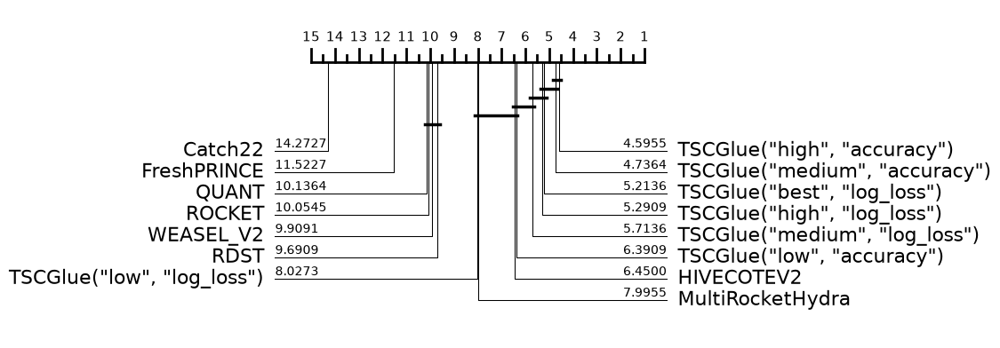

LogLoss: 110 datasets


/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


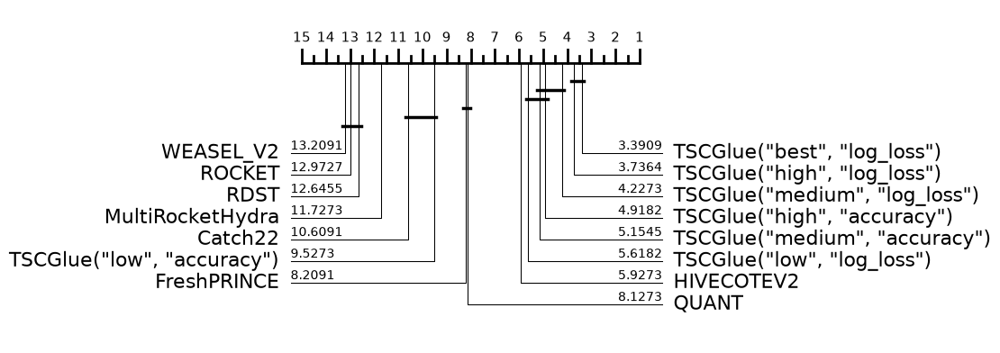

F1: 110 datasets


/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


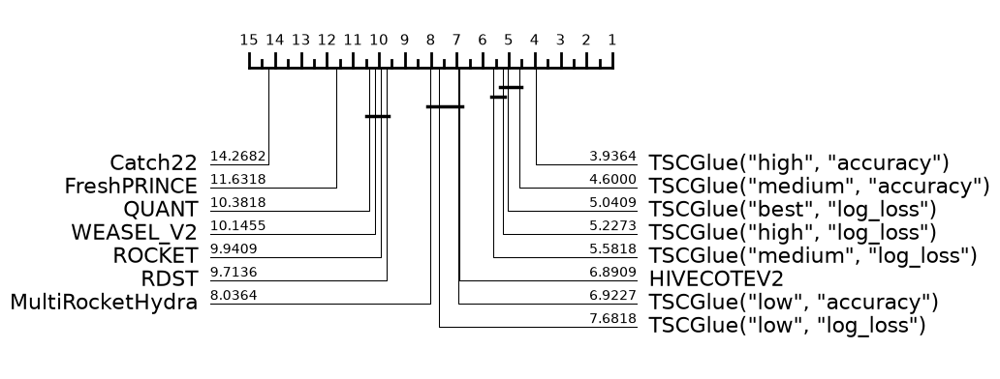

ROCAUC: 110 datasets


/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


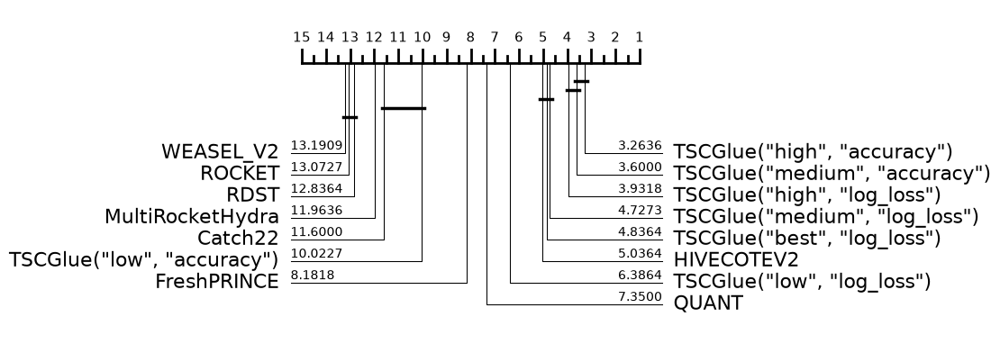

In [9]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd

for label, subdir, metric in [
    ("Accuracy", "Accuracy", "accuracy"),
    ("LogLoss", "LogLoss", "logloss"),
    ("F1", "F1", "f1"),
    ("ROCAUC", "AUROC", "auroc"),
]:
    fig_dir = GENERATED_RESULTS / "tscbench" / subdir
    pkl_path = fig_dir / "figures" / f"tscbench_{metric}_critical_difference.pickle"
    ranks_path = fig_dir / f"{metric}_ranks.csv"

    if not pkl_path.exists():
        print(f"{label}: no figure found at {pkl_path} (evaluate_classifiers_by_problem "
              "may have skipped it — check for missing results above)")
        continue

    n_datasets = pd.read_csv(ranks_path, index_col=0, header=None, skiprows=1).dropna().shape[0]
    print(f"{label}: {n_datasets} datasets")

    with open(pkl_path, "rb") as f:
        fig = pickle.load(f)
    display(fig)
    plt.close(fig)

Accuracy (TSCGlue accuracy): 110 datasets


/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


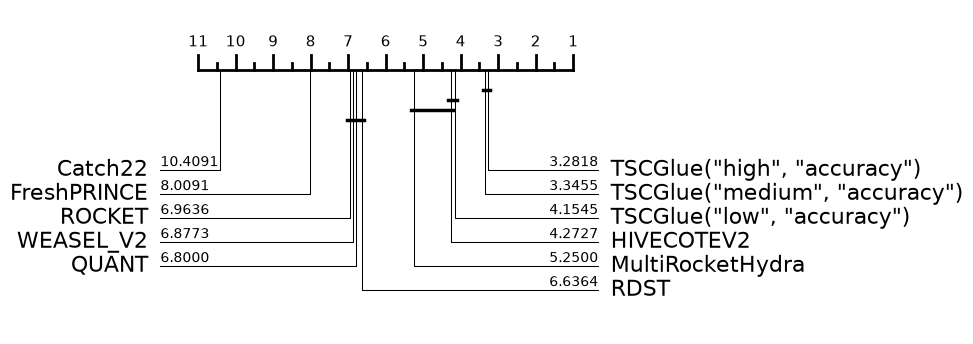

LogLoss (TSCGlue log_loss): 110 datasets


/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


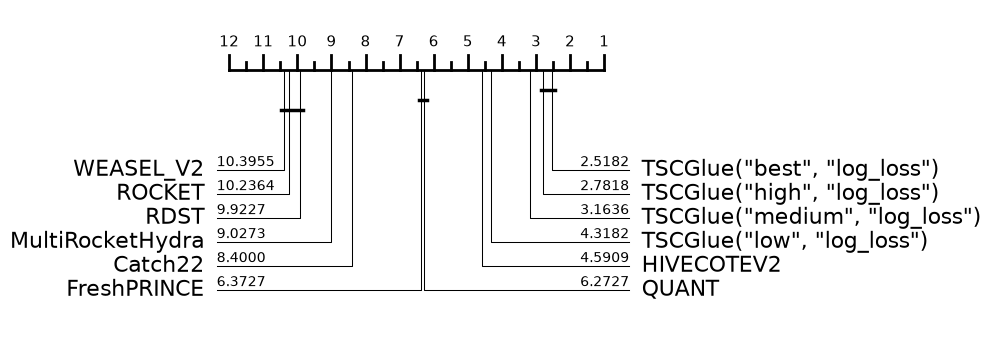

F1 (TSCGlue accuracy): 110 datasets


/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


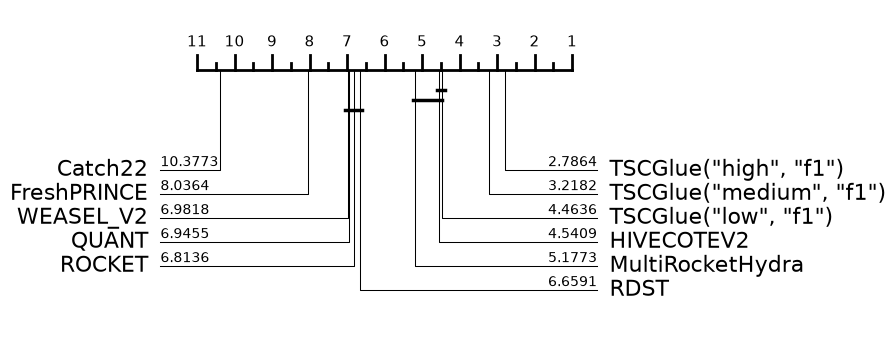

ROCAUC (TSCGlue accuracy): 110 datasets


/export/home/gpetelin/TSCbench/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


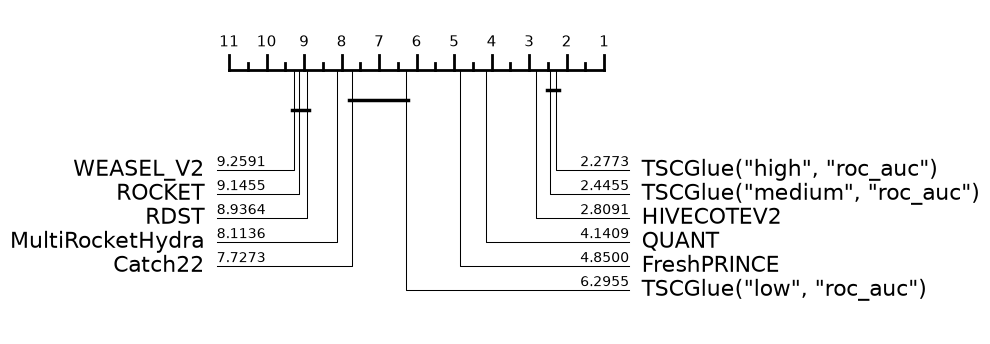

In [10]:
from aeon.visualisation import plot_critical_difference

# shown: metric name put on the TSCGlue labels. F1/ROCAUC plot the accuracy-tuned
# runs, relabelled as the metric being plotted.
for label, subdir, metric, shown in [
    ("Accuracy", "Accuracy", "accuracy", "accuracy"),
    ("LogLoss", "LogLoss", "logloss", "log_loss"),
    ("F1", "F1", "f1", "f1"),
    ("ROCAUC", "AUROC", "auroc", "roc_auc"),
]:
    variant = "log_loss" if metric == "logloss" else "accuracy"
    means = pd.read_csv(
        GENERATED_RESULTS / "tscbench" / subdir / f"{metric}_mean.csv",
        index_col=0, header=None, skiprows=1,
    ).set_axis(EVAL_NAMES, axis=1)
    cols = [c for c in means.columns if not c.startswith("TSCGlue-") or c.endswith(f"-{variant}")]
    means = means[cols].dropna()
    labels = [c.removesuffix(f"-{variant}") + f"-{shown}" if c.startswith("TSCGlue-") else c for c in cols]
    print(f"{label} (TSCGlue {variant}): {means.shape[0]} datasets")

    fig, ax = plot_critical_difference(
        means.values, labels, lower_better=(metric == "logloss")
    )
    display(fig)
    plt.close(fig)
